# Single-stock IV term structure

Fetches ATM implied vol across standard tenors (**1W / 1M / 3M / 6M**) for a list of underlyings via `yfinance.Ticker().option_chain()`, then linearly interpolates in total variance (σ²·T) to hit each target tenor exactly.

**Notes & caveats**
- Yahoo options data is **US-listed only** — Euro names like ASML.AS / MC.PA won't return a chain.
- `.option_chain(expiry)` makes one HTTP call per expiry, so ~10 tickers × ~15 expiries ≈ 1–2 minutes total. Can be rate-limited.
- Near-dated (0DTE/1DTE) IVs are noisy — we skip anything with <2 days to expiry.
- ATM IV = average of call + put IV at the strike nearest spot (a crude put-call average; no forward adjustment).

In [1]:
import datetime as dt
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

TICKERS = ["SPY", "QQQ", "NVDA", "AAPL", "MSFT", "TSLA", "GOOGL", "AMZN", "META"]
TARGET_TENORS_DAYS = [7, 30, 90, 180]
TENOR_LABELS = {7: "1W", 30: "1M", 90: "3M", 180: "6M"}
MIN_DAYS_TO_EXPIRY = 2

# Bloomberg-ish palette for plotting
AMBER = "#FA8C00"; BG = "#000000"; FG = "#E8E8E8"; GRID = "#333333"
LINE_COLORS = [AMBER, "#00D9FF", "#4CFF4C", "#BE85FF", "#FFE14C", "#FF9EC6",
               "#FF4C4C", "#9EFFCB", "#FFB74C"]

## Fetch option chains

For each ticker: pull the list of expiries, skip near-dated garbage, grab the ATM IV from each remaining expiry.

In [2]:
def atm_iv(tk: yf.Ticker, expiry: str, spot: float) -> float:
    """Mean of call + put IV at the strike nearest spot. NaN on any failure."""
    try:
        chain = tk.option_chain(expiry)
    except Exception:
        return np.nan
    calls, puts = chain.calls, chain.puts
    if calls.empty or puts.empty:
        return np.nan
    k_call = calls.iloc[(calls["strike"] - spot).abs().argsort()[:1]]
    k_put = puts.iloc[(puts["strike"] - spot).abs().argsort()[:1]]
    ivs = [
        float(k_call["impliedVolatility"].iloc[0]),
        float(k_put["impliedVolatility"].iloc[0]),
    ]
    ivs = [x for x in ivs if 0.02 < x < 3.0]  # sanity bounds
    return float(np.mean(ivs)) if ivs else np.nan


def fetch_curve(ticker: str):
    tk = yf.Ticker(ticker)
    try:
        fi = tk.fast_info
        spot = float(fi.get("last_price") or fi.get("lastPrice"))
    except Exception:
        spot = float(tk.history(period="1d")["Close"].iloc[-1])
    today = dt.date.today()
    rows = []
    for exp in tk.options:
        days = (dt.datetime.strptime(exp, "%Y-%m-%d").date() - today).days
        if days < MIN_DAYS_TO_EXPIRY:
            continue
        iv = atm_iv(tk, exp, spot)
        if not np.isnan(iv):
            rows.append((days, iv))
    curve = pd.DataFrame(rows, columns=["days", "iv"]).sort_values("days").reset_index(drop=True)
    return spot, curve


raw = {}
for t in TICKERS:
    try:
        spot, curve = fetch_curve(t)
        raw[t] = {"spot": spot, "curve": curve}
        iv_lo = curve["iv"].min() * 100 if not curve.empty else float("nan")
        iv_hi = curve["iv"].max() * 100 if not curve.empty else float("nan")
        print(f"{t:6s} spot={spot:>9.2f}  {len(curve):>2d} expiries  IV {iv_lo:>5.1f}% – {iv_hi:>5.1f}%")
    except Exception as e:
        print(f"{t:6s} FAIL {type(e).__name__}: {e}")
        raw[t] = None

SPY    spot=   713.94  29 expiries  IV   9.2% –  20.7%
QQQ    spot=   663.88  28 expiries  IV  11.9% –  29.9%
NVDA   spot=   208.27  23 expiries  IV  24.4% –  44.7%
AAPL   spot=   271.06  22 expiries  IV  15.7% –  35.6%
MSFT   spot=   424.62  21 expiries  IV  20.4% –  56.7%
TSLA   spot=   376.30  22 expiries  IV  27.8% –  49.1%
GOOGL  spot=   344.40  22 expiries  IV  18.2% –  48.0%
AMZN   spot=   263.99  23 expiries  IV  20.2% –  61.7%
META   spot=   675.03  22 expiries  IV  21.1% –  62.5%


## Interpolate to standard tenors

Listed expiries don't fall on 7/30/90/180 days exactly, so we interpolate in **total variance** (σ²·T) between the two bracketing expiries — this is the standard way because variance is additive in time while IV isn't.

In [ ]:
def interp_iv(curve: pd.DataFrame, target_days: int) -> float:
    if curve.empty:
        return np.nan
    d = curve["days"].to_numpy()
    iv = curve["iv"].to_numpy()
    if target_days <= d[0]:
        return float(iv[0])
    if target_days >= d[-1]:
        return float(iv[-1])
    tv = (iv ** 2) * d  # total variance at each listed expiry
    tv_t = np.interp(target_days, d, tv)
    return float(np.sqrt(tv_t / target_days))


rows = []
for t in TICKERS:
    r = raw.get(t)
    if r is None:
        rows.append([t] + [np.nan] * len(TARGET_TENORS_DAYS))
        continue
    rows.append([t] + [interp_iv(r["curve"], d) for d in TARGET_TENORS_DAYS])

surface = (
    pd.DataFrame(rows, columns=["ticker"] + [TENOR_LABELS[d] for d in TARGET_TENORS_DAYS])
    .set_index("ticker")
)
(surface * 100).round(1)

,1W,1M,3M,6M
ticker,,,,
SPY,14.6,15.7,16.7,17.9
QQQ,20.0,20.5,21.2,23.1
NVDA,38.2,42.4,39.3,41.5
AAPL,35.6,27.4,26.4,27.6
MSFT,56.7,38.7,33.3,32.9
TSLA,39.4,40.3,42.4,45.5
GOOGL,48.0,36.2,33.7,35.0
AMZN,61.7,40.7,35.5,36.1
META,62.5,42.6,37.0,38.1


## Term structure — one line per name

Log-x scale keeps the short end legible alongside 6M+.

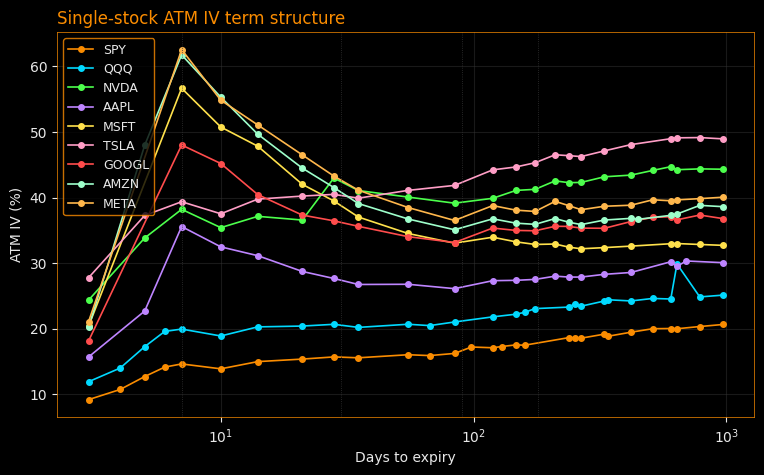

In [4]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)

for i, t in enumerate(TICKERS):
    r = raw.get(t)
    if r is None or r["curve"].empty:
        continue
    color = LINE_COLORS[i % len(LINE_COLORS)]
    c = r["curve"]
    ax.plot(c["days"], c["iv"] * 100, "-o", color=color, markersize=4, linewidth=1.2, label=t)

for d in TARGET_TENORS_DAYS:
    ax.axvline(d, color=GRID, linestyle=":", linewidth=0.6)

ax.set_xscale("log")
ax.set_xlabel("Days to expiry", color=FG)
ax.set_ylabel("ATM IV (%)", color=FG)
ax.set_title("Single-stock ATM IV term structure", color=AMBER, loc="left", fontsize=12)
ax.tick_params(colors=FG)
ax.grid(color=GRID, alpha=0.5)
for s in ax.spines.values():
    s.set_color(AMBER)
    s.set_linewidth(0.5)
ax.legend(loc="best", facecolor=BG, edgecolor=AMBER, labelcolor=FG, fontsize=9)
plt.show()

## Heatmap — interpolated surface

Rows = tickers, columns = standard tenors. Cell values are ATM IV in %.

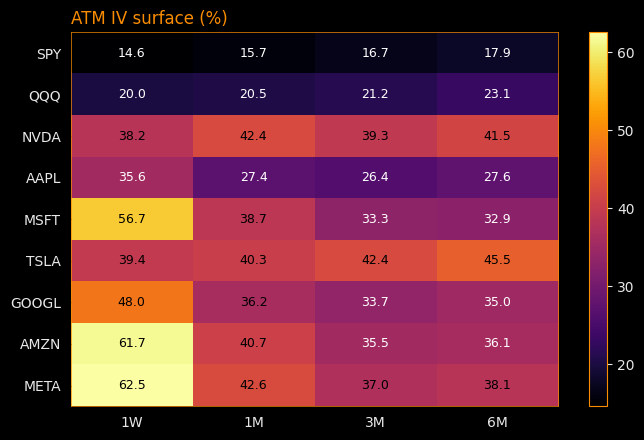

In [5]:
fig, ax = plt.subplots(figsize=(7, max(4, 0.5 * len(TICKERS))), facecolor=BG)
ax.set_facecolor(BG)

data = (surface * 100).to_numpy()
im = ax.imshow(data, aspect="auto", cmap="inferno")

ax.set_xticks(range(surface.shape[1]))
ax.set_xticklabels(surface.columns, color=FG)
ax.set_yticks(range(surface.shape[0]))
ax.set_yticklabels(surface.index, color=FG)

for i in range(surface.shape[0]):
    for j in range(surface.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                    color="white" if v < np.nanmedian(data) else "black", fontsize=9)

ax.set_title("ATM IV surface (%)", color=AMBER, loc="left", fontsize=12)
for s in ax.spines.values():
    s.set_color(AMBER)
    s.set_linewidth(0.5)

cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=FG)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=FG)
cbar.outline.set_edgecolor(AMBER)

plt.tight_layout()
plt.show()

## Term-structure slope

A simple summary: **6M − 1W IV**. Positive = contango (long end richer, typical); negative = backwardation (short-dated stress).

In [6]:
slope = ((surface["6M"] - surface["1W"]) * 100).round(2).sort_values()
slope.name = "6M − 1W (vol pts)"
slope.to_frame()

,6M − 1W (vol pts)
ticker,
AMZN,-25.68
META,-24.40
MSFT,-23.79
GOOGL,-12.96
AAPL,-7.97
QQQ,3.14
SPY,3.27
NVDA,3.27
TSLA,6.15
